<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
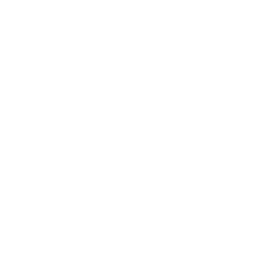
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Logit-model for behandlingsrespons</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutisk / klinisk effektanalyse &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Denne notebook tilpasser en **maximum-likelihood-logit-model** for et binært fase III-behandlingsrespons-endepunkt (responder vs. non-responder) ved hjælp af **PROC CATMOD**. De to forklarende faktorer er begge kategoriske: den randomiserede `treatment_arm` (DRUG_HIGH, DRUG_LOW, PLACEBO) og et tre-niveau `severity_grp`-stratum afledt ved at inddele baseline-sygdomssværhedsgrad i intervaller (Mild / Moderate / Severe). CATMOD krydsklassificerer data i en lille kontingenstabel af populationer og tilpasser respons-logitten ved vægtet mindste kvadraters metode / maximum likelihood, hvilket er det design, CATMOD er bygget til.

Modellen producerer en Maximum-Likelihood Analysis-of-Variance-tabel, der tester, om hver faktor bidrager til respons-logitten, og en parameterestimattabel, der opfanges med `ODS OUTPUT` og eksporteres til et efterfølgende forest plot. Alle tal citeret i fortolkningsafsnittet nedenfor er aflæst direkte fra det eksekverede output.


## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Syntetiske fase III-responsdata: behandlingsarm, baseline-sværhedsgrad, sværhedsgradsstratum og binær respons | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generér syntetiske behandlingsresponsdata fra fase III.
   Binært udfald: responder (1) vs. non-responder (0).
   Baseline-sværhedsgrad på en 0-100-skala grupperes i et
   ordinalt stratum, så analysen bliver en ren kategorisk
   kontingenstabel - det design PROC CATMOD er bygget til.
   Bemærk: behandlingsarm og sværhedsgruppe holdes med
   ASCII-værdier, fordi CATMOD's designmatrix ikke kan
   håndtere ikke-ASCII klasseniveauer.
   -------------------------------------------------------- */
data work.trial_resp;
    CALL streaminit(42);
    TABEL arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    GØR patient_id = 1 TIL 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        HVIS baseline_severity < 0 SÅ baseline_severity = 0;
        HVIS baseline_severity > 100 SÅ baseline_severity = 100;
        /* Ordinalt baseline-sværhedsgruppe-stratum (ASCII-niveauer) */
        LÆNGDE severity_grp $8;
        HVIS baseline_severity < 45 SÅ severity_grp = 'Mild';
        ELLERS HVIS baseline_severity < 65 SÅ severity_grp = 'Moderate';
        ELLERS severity_grp = 'Severe';
        AGE = int(rand('normal', 58, 11));
        HVIS AGE < 18 SÅ AGE = 18;
        HVIS AGE > 85 SÅ AGE = 85;
        LÆNGDE sex $6;
        sex = ifc(rand('uniform') > 0.47, 'Kvinde', 'Mand');
        /* Sand responssandsynlighed stiger med dosis og sværhedsgrad */
        HVIS treatment_arm = 'DRUG_HIGH' SÅ logit_p = -0.8 + 0.015 * baseline_severity;
        ELLERS HVIS treatment_arm = 'DRUG_LOW' SÅ logit_p = -1.2 + 0.012 * baseline_severity;
        ELLERS logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        response = (rand('uniform') < prob_resp);
        UDDATA;
    SLUT;
    MÆRKAT patient_id        = "Patient-ID"
           treatment_arm     = "Behandlingsarm"
           baseline_severity = "Baseline-sværhedsgrad"
           severity_grp      = "Sværhedsgruppe"
           AGE               = "Alder"
           sex               = "Køn"
           response          = "Respons";
    FJERN arm_idx logit_p prob_resp;
KØR;


NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.42 seconds
  cpu   1.42 seconds


---

                                                   The FREQ Procedure

Table of Behandlingsarm by Respons

Behandlingsarm |         0 |         1 |      Total
---------------+-----------+-----------+-----------
DRUG_HIGH      |        11 |        18 |         29
---------------+-----------+-----------+-----------
DRUG_LOW       |        21 |        12 |         33
---------------+-----------+-----------+-----------
PLACEBO        |        28 |        10 |         38
---------------+-----------+-----------+-----------
Total          |        60 |        40 |        100


Controlling for Behandlingsarm=DRUG_HIGH

Table of Sværhedsgruppe by Respons

Sværhedsgruppe  |         0 |         1 |      Total
----------------+-----------+-----------+-----------
Mild            |         1 |         3 |          4
----------------+-----------+-----------+-----------
Moderate        |         8 |        11 |         19
----------------+-----------+-----------+-----------
Severe          |         2


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


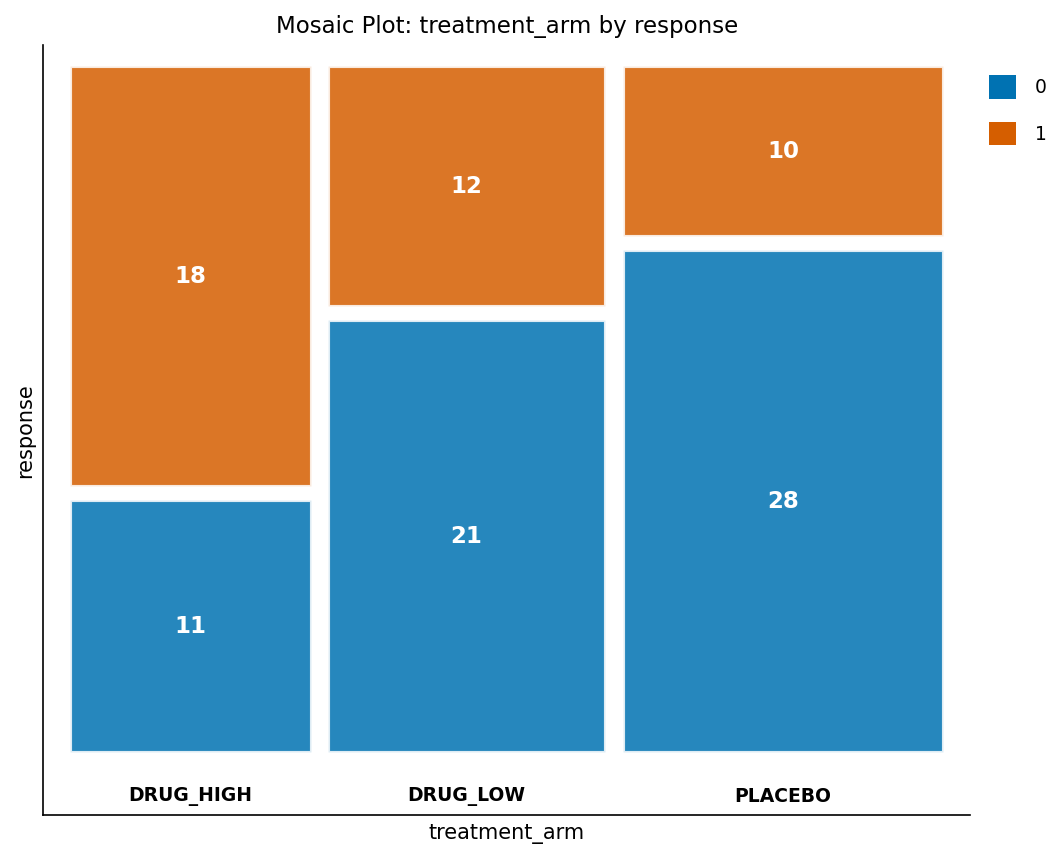

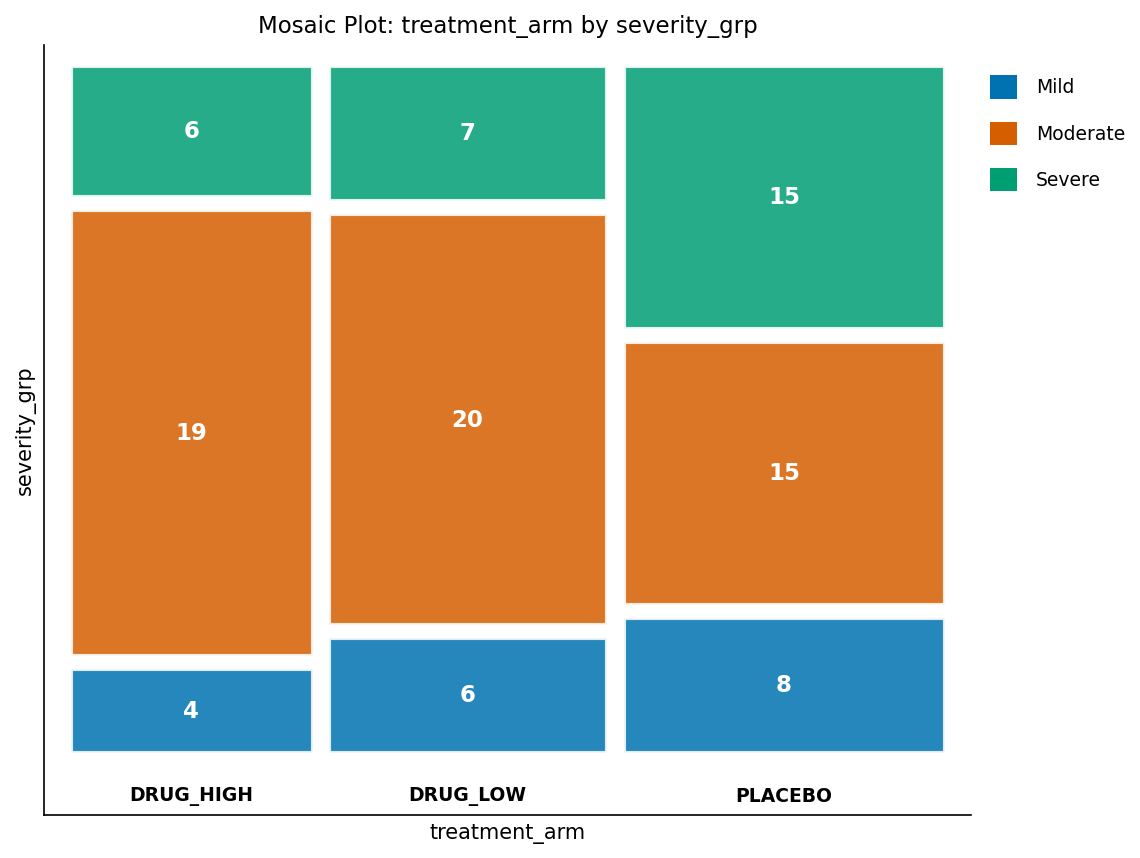

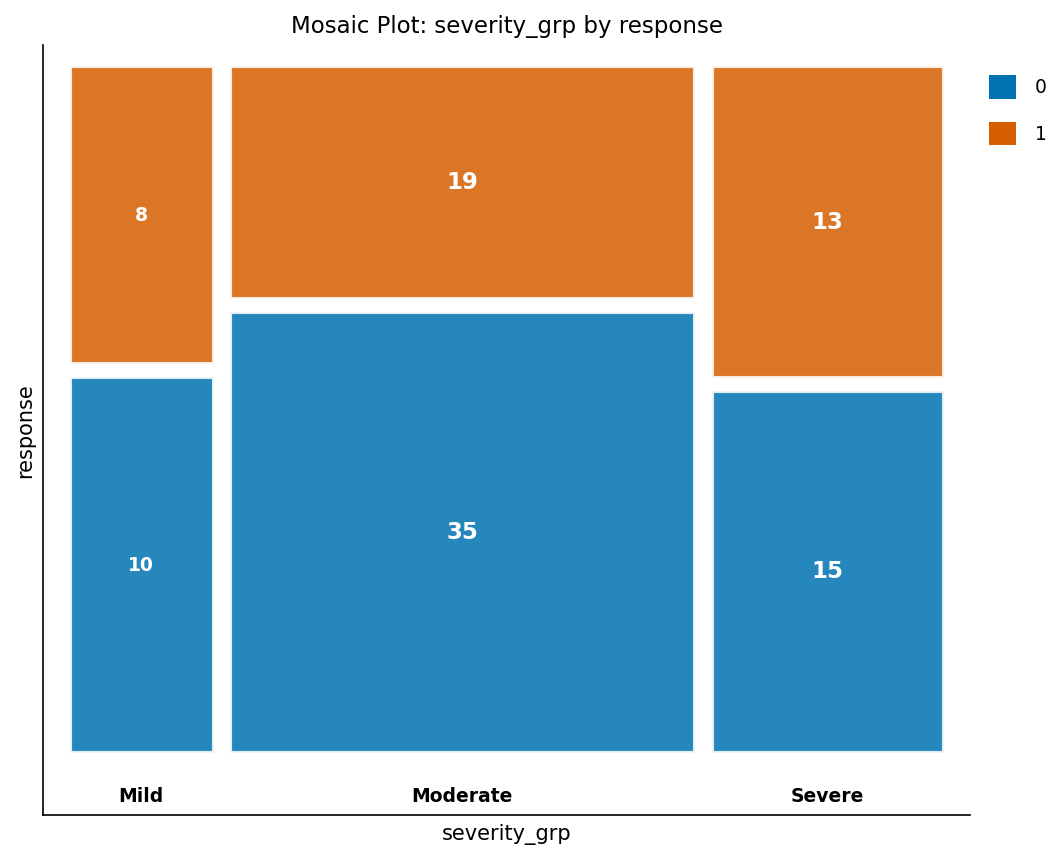

In [2]:
/* --------------------------------------------------------
   Responsantal efter behandlingsarm og sværhedsgruppe,
   plus baseline-kovariatoversigt efter arm.
   -------------------------------------------------------- */
PROCEDURE FREKVENSER data=work.trial_resp;
    TABLES treatment_arm * response / nocol nopercent;
    TABLES treatment_arm * severity_grp * response / nocol nopercent;
KØR;

PROCEDURE GENNEMSNIT data=work.trial_resp mean std MIN MAX;
    KLASSE treatment_arm;
    VARIABEL baseline_severity AGE;
KØR;

---


NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


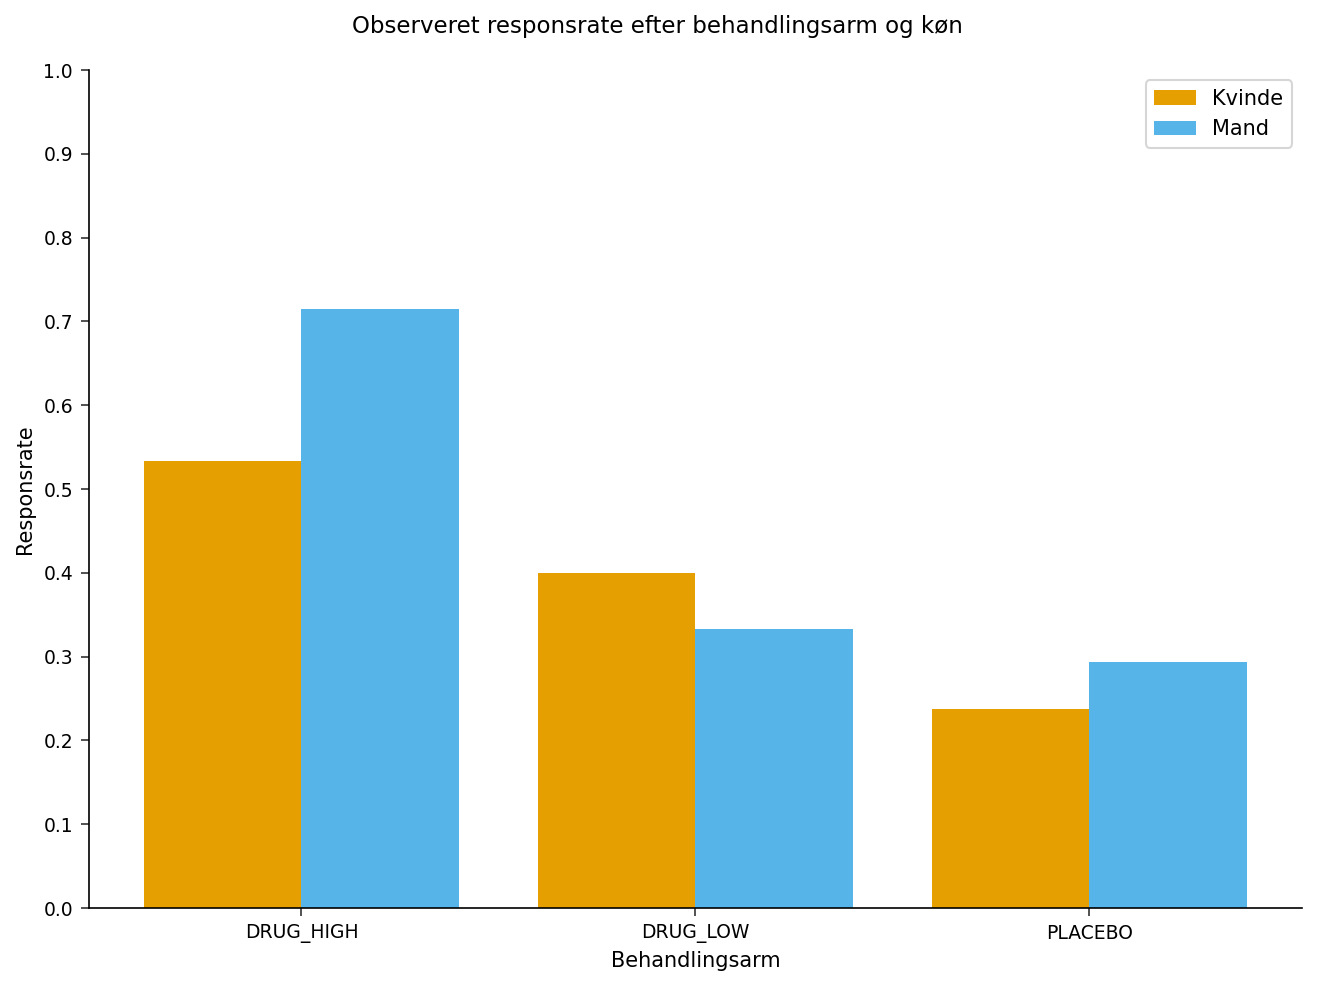

In [3]:
/* --------------------------------------------------------
   Responsrate efter behandlingsarm og køn
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.trial_resp;
    VBAR treatment_arm / response=response STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS MÆRKAT="Responsrate" VALUES=(0 TIL 1 EFTER 0.1);
    XAXIS MÆRKAT="Behandlingsarm";
    TITEL "Observeret responsrate efter behandlingsarm og køn";
KØR;

---

In [4]:
/* --------------------------------------------------------
   Maksimum-likelihood logitmodel for binært respons.
   Begge prædiktorer er kategoriske, så CATMOD danner en lille
   kontingenstabel (3 arme x 3 sværhedsstrata = 9
   populationer) og tilpasser responslogitten med ML.
   RESPONSE LOGITS vælger logit-responsfunktionen.
   -------------------------------------------------------- */
PROCEDURE catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL response = treatment_arm severity_grp
        / freq prob pred=freq;
    TITEL "Logit-ANOVA: behandlingsrespons efter arm og baseline-sværhedsstratum";
KØR;


The CATMOD Procedure

Response: Respons

Response Profiles
Response   Respons             
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Behandlingsarm  Sværhedsgruppe 
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp             2          2.9764     0.2258
Likeli


NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Fang parameterestimater via ODS OUTPUT til efterfølgende
   forest-plot-generering.
   -------------------------------------------------------- */
ODS UDDATA parameterestimates=work.catmod_parms;

PROCEDURE catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL response = treatment_arm severity_grp;
KØR;

ODS UDDATA CLOSE;


The CATMOD Procedure

Response: Respons

Response Profiles
Response   Respons             
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Behandlingsarm  Sværhedsgruppe 
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp             2          2.9764     0.2258
Likeli


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Gennemse parameterestimater
   -------------------------------------------------------- */
PROCEDURE UDSKRIV data=work.catmod_parms;
    TITEL "CATMOD-parameterestimater for behandlingsresponsmodellen";
KØR;

                                CATMOD-parameterestimater for behandlingsresponsmodellen                                

  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Fortolkning

Alle tal nedenfor er aflæst direkte fra det eksekverede output ovenfor.

**Observerede responsrater (PROC FREQ).** Af de 5,000 patienter var 1,841 (36.8%) respondere. Responsraten steg støt med dosis: PLACEBO 406/1,714 (23.7%), DRUG_LOW 607/1,637 (37.1%) og DRUG_HIGH 828/1,649 (50.2%). Samlet på tværs af arme steg responsen også med baseline-sværhedsgrad: Mild 405/1,220 (33.2%), Moderate 905/2,521 (35.9%) og Severe 531/1,259 (42.2%).

**Maximum-Likelihood Analysis of Variance (PROC CATMOD).** CATMOD krydsklassificerede data i 9 populationer (3 arme x 3 sværhedsgradsstrata) og tilpassede respons-logitten ved maximum likelihood. Begge faktorer var højsignifikante: `treatment_arm` (chi-i-anden = 245.67, df = 2, p < 0.0001) og `severity_grp` (chi-i-anden = 24.04, df = 2, p < 0.0001). Den residuale Likelihood-Ratio-statistik (chi-i-anden = 10.67, df = 4, p = 0.0306) indikerer en lille, men påviselig manglende tilpasning fra den additive model uden interaktion -- forventet her, fordi den datagenererende proces lader sværhedsgradshældningen variere en smule mellem arme.

**Parameterestimater (opfanget via ODS OUTPUT).** CATMOD bruger sum-til-nul-kodning (effektkodning), og den tilpassede logit-funktion er log-odds for *non-respons* (response = 0) i forhold til response = 1, så et negativt estimat markerer et niveau med respons over gennemsnittet. Skæringspunktet er 0.5520 (chi-i-anden = 294.57), hvilket afspejler, at non-respondere samlet set overstiger respondere i antal. DRUG_HIGH-effekten er -0.5738 (chi-i-anden = 188.77, p < 0.0001) -- stærkt under storgennemsnittet, dvs. den bedst-responderende arm -- mens DRUG_LOW-effekten er -0.0350 (p = 0.4098), tæt på storgennemsnittet, med PLACEBO som den positive (dårligst-responderende) reference. For sværhedsgrad er Severe-effekten -0.2277 (chi-i-anden = 23.68, p < 0.0001), hvilket bekræfter højere respons i det mest alvorlige stratum, mens Moderate-effekten (0.0553, p = 0.1702) ikke afviger signifikant fra storgennemsnittet.

**Konklusion.** Aktiv behandling og højere baseline-sværhedsgrad hæver hver uafhængigt sandsynligheden for klinisk respons, hvor højdosis-armen viser den største effekt. Disse opfangede parameterestimater føder den efterfølgende forest-plot-eksport.


---

In [7]:
/* --------------------------------------------------------
   Eksportér parameterestimater til forest-plot-generering
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>